# OOS Testing: Task 1 Baseline vs Task 2 Enhanced

This notebook runs the frozen Task 1 and Task 2 strategies on the out-of-sample period only. Training data is used only as historical warm-up for rolling indicators and macro state. No parameters are tuned, searched, or changed in this file.

Sections:
1. Imports and frozen settings
2. OOS data reconstruction and macro inputs
3. Purged strategy runners
4. OOS performance and diagnostics
5. Charts and findings


## 1. Imports And Frozen Settings
The strategy settings below are copied from the final training notebooks. Treat them as locked before evaluating the holdout period.


In [1]:
import os
import sys
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

ROOT = Path.cwd().resolve()
if not (ROOT / 'data').exists():
    for parent in ROOT.parents:
        if (parent / 'data').exists():
            ROOT = parent
            break

sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / 'tasks' / 'task_1'))
sys.path.insert(0, str(ROOT / 'tasks' / 'task_2'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.25

from tasks.task_1.analytics import performance_stats, rolling_sharpe
from tasks.task_1.signals.signal_layer1 import layer1_signal as task1_layer1_signal
from tasks.task_1.signals.signal_layer2 import layer2_signal as task1_layer2_signal
from tasks.task_1.portfolio.slot_manager import build_positions as task1_build_positions
from tasks.task_1.portfolio.portfolio_manager import build_portfolio as task1_build_portfolio

from tasks.task_2.signals.signal_layer1_enhanced import (
    layer1_signal as task2_layer1_signal,
    regime_strength as task2_regime_strength,
)
from tasks.task_2.signals.signal_layer2_enhanced import layer2_signal as task2_layer2_signal
from tasks.task_2.signals.macro_signal import (
    dollar_signal,
    equity_signal,
    credit_signal,
    macro_regime_score,
    vol_percentile,
)
from tasks.task_2.portfolio.slot_manager_enhanced import build_positions as task2_build_positions
from tasks.task_2.portfolio.portfolio_manager_enhanced import build_portfolio as task2_build_portfolio


In [2]:
OOS_START = pd.Timestamp('2020-01-01')
OOS_END = pd.Timestamp('2026-05-18')
EMBARGO_BARS = 310  # SMA200 + max enhanced Layer 1 slope lookback 110

TASK1_PARAMS = dict(
    filter_fast=50, filter_slow=200, slope_lookback=100,
    ema_window=14, rsi_window=14, rsi_long_level=50.0,
    rsi_level=60.0, rsi_flag_window=5,
    bb_window=100, bb_num_std=2.0, atr_window=50, sl_mult=3.0,
    risk_per_trade=0.01, max_weight=0.20, leverage_cap=2.50, exec_lag=1,
)

TASK2_PARAMS = dict(
    filter_fast=50, filter_slow=200, lookbacks=None,
    ema_window=14, rsi_window=14, rsi_long_level=50.0,
    rsi_level=60.0, rsi_flag_window=5, rsi_short_cap=50.0,
    bb_window=100, bb_num_std=2.0, atr_window=50,
    sar_initial_mult=2.5, sar_af_start=0.01, sar_af_step=0.03,
    sar_af_max=0.20, sar_grace_period=5,
    sl_mult=3.0, risk_per_trade=0.01, max_weight=0.20,
    leverage_cap=2.50, exec_lag=1, tx_cost_bps=2.0,
    macro_alpha=0.5, macro_fast=50, macro_slow=200,
    vol_cap_pct=0.80, vol_dampen=0.5,
)

print(f'Project root : {ROOT}')
print(f'OOS period   : {OOS_START.date()} -> {OOS_END.date()}')
print(f'Embargo bars : {EMBARGO_BARS}')


Project root : /Users/faisal/Desktop/BUSI97075-backtesting
OOS period   : 2020-01-01 -> 2026-05-18
Embargo bars : 310


## 2. Data Loading And OOS Price Reconstruction
The testing folder provides returns, not close prices. The OOS close-price path is reconstructed by anchoring cumulative test returns to the last training close. This lets rolling indicators use the pre-2020 history available at the start of the holdout.


In [3]:
train_prices = pd.read_csv(ROOT / 'data/training/close_prices_final.csv', index_col=0, parse_dates=True).sort_index()
test_returns = pd.read_csv(ROOT / 'data/testing/returns.csv', index_col=0, parse_dates=True).sort_index()

test_returns = test_returns.loc[OOS_START:OOS_END, train_prices.columns]
test_prices = (1.0 + test_returns).cumprod().mul(train_prices.iloc[-1], axis=1)
prices_all = pd.concat([train_prices, test_prices]).sort_index()
returns_all = prices_all.pct_change().fillna(0.0)
oos_index = test_returns.index
assets = pd.read_csv(ROOT / 'data/raw/assets.csv')
factor_oos = test_returns.mean(axis=1)
factor_oos.name = 'EW Factor OOS'

assert train_prices.index.max() < OOS_START
assert oos_index.min() == OOS_START
assert oos_index.max() == OOS_END
assert list(test_returns.columns) == list(train_prices.columns)

print(f'Training warm-up : {train_prices.index[0].date()} -> {train_prices.index[-1].date()} | {len(train_prices):,} rows')
print(f'OOS returns      : {oos_index[0].date()} -> {oos_index[-1].date()} | {len(oos_index):,} rows')
print(f'Commodities      : {prices_all.shape[1]}')


Training warm-up : 2005-10-05 -> 2019-12-31 | 3,715 rows
OOS returns      : 2020-01-01 -> 2026-05-18 | 1,664 rows
Commodities      : 23


In [4]:
def _load_external_history(file_name: str) -> pd.DataFrame:
    train = pd.read_csv(ROOT / 'data/external/training' / file_name, index_col=0, parse_dates=True).sort_index()
    test = pd.read_csv(ROOT / 'data/external/testing' / file_name, index_col=0, parse_dates=True).sort_index()
    return pd.concat([train, test.loc[OOS_START:OOS_END]]).sort_index()

external_all = {
    'fx_spot': _load_external_history('fx_spot_levels.csv'),
    'equity': _load_external_history('equity_indices_levels.csv'),
    'credit': _load_external_history('credit_spreads_levels.csv'),
    'fx_vol': _load_external_history('atm_vols_levels.csv'),
}

for label, frame in external_all.items():
    print(f'{label:8s}: {frame.index[0].date()} -> {frame.index[-1].date()} | {frame.shape}')


fx_spot : 2005-10-05 -> 2026-05-18 | (5379, 15)
equity  : 2005-10-05 -> 2026-05-18 | (5379, 9)
credit  : 2005-10-05 -> 2026-05-18 | (5379, 4)
fx_vol  : 2005-10-05 -> 2026-05-18 | (5379, 45)


## 3. Purged Strategy Runners
The runners below compute indicators with historical warm-up, but purge all pre-OOS entry events and force positions flat before the OOS boundary. The reported P&L is sliced strictly to testing dates.


In [5]:
def _purge_layer2(layer2: pd.DataFrame) -> pd.DataFrame:
    purged = layer2.copy()
    purged.loc[purged.index < OOS_START] = 0.0
    return purged


def _slice_oos(series_or_frame):
    return series_or_frame.reindex(oos_index)


def _compute_task2_macro(external: dict, params: dict) -> tuple[pd.Series | None, pd.Series | None]:
    components = {}
    for name, func, key in [
        ('dollar', dollar_signal, 'fx_spot'),
        ('equity', equity_signal, 'equity'),
        ('credit', credit_signal, 'credit'),
    ]:
        try:
            components[name] = func(external[key], fast=params['macro_fast'], slow=params['macro_slow'])
        except (KeyError, ValueError):
            pass
    macro_score = macro_regime_score(**components) if components else None
    try:
        vol_pct = vol_percentile(external['fx_vol'])
    except (KeyError, ValueError):
        vol_pct = None
    return macro_score, vol_pct


def run_task1_purged_oos(prices: pd.DataFrame, returns: pd.DataFrame, params: dict):
    layer1 = task1_layer1_signal(prices, params['filter_fast'], params['filter_slow'], params['slope_lookback'])
    layer2 = task1_layer2_signal(
        prices, layer1=layer1,
        ema_window=params['ema_window'], rsi_window=params['rsi_window'],
        rsi_long_level=params['rsi_long_level'], rsi_level=params['rsi_level'],
        rsi_flag_window=params['rsi_flag_window'],
    )
    positions = task1_build_positions(
        prices, layer1=layer1, layer2=_purge_layer2(layer2),
        bb_window=params['bb_window'], bb_num_std=params['bb_num_std'],
        atr_window=params['atr_window'], sl_mult=params['sl_mult'],
    )
    positions.loc[positions.index < OOS_START] = 0.0
    weights, port_returns = task1_build_portfolio(
        positions, prices, returns,
        atr_window=params['atr_window'], sl_mult=params['sl_mult'],
        risk_per_trade=params['risk_per_trade'], max_weight=params['max_weight'],
        leverage_cap=params['leverage_cap'], exec_lag=params['exec_lag'],
    )
    assert positions.loc[OOS_START].abs().sum() == 0
    return positions, weights, port_returns, {'layer1': layer1, 'layer2': _purge_layer2(layer2)}


def run_task2_purged_oos(prices: pd.DataFrame, returns: pd.DataFrame, external: dict, params: dict):
    macro_score, vol_pct = _compute_task2_macro(external, params)
    strength = task2_regime_strength(
        prices, fast=params['filter_fast'], slow=params['filter_slow'], lookbacks=params['lookbacks'],
        macro_score=macro_score, vol_pct=vol_pct, macro_alpha=params['macro_alpha'],
        vol_cap_pct=params['vol_cap_pct'], vol_dampen=params['vol_dampen'],
    )
    layer1 = task2_layer1_signal(prices, params['filter_fast'], params['filter_slow'], params['lookbacks'])
    layer2 = task2_layer2_signal(
        prices, layer1=layer1,
        ema_window=params['ema_window'], rsi_window=params['rsi_window'],
        rsi_long_level=params['rsi_long_level'], rsi_level=params['rsi_level'],
        rsi_flag_window=params['rsi_flag_window'],
    )
    positions = task2_build_positions(
        prices, layer1=layer1, layer2=_purge_layer2(layer2),
        bb_window=params['bb_window'], bb_num_std=params['bb_num_std'],
        atr_window=params['atr_window'], sar_initial_mult=params['sar_initial_mult'],
        sar_af_start=params['sar_af_start'], sar_af_step=params['sar_af_step'],
        sar_af_max=params['sar_af_max'], sar_grace_period=params['sar_grace_period'],
        rsi_window=params['rsi_window'], rsi_short_cap=params['rsi_short_cap'],
    )
    positions.loc[positions.index < OOS_START] = 0.0
    weights, port_returns = task2_build_portfolio(
        positions, prices, returns, regime_strength=strength,
        atr_window=params['atr_window'], sl_mult=params['sl_mult'],
        risk_per_trade=params['risk_per_trade'], max_weight=params['max_weight'],
        leverage_cap=params['leverage_cap'], exec_lag=params['exec_lag'],
        tx_cost_bps=params['tx_cost_bps'],
    )
    assert positions.loc[OOS_START].abs().sum() == 0
    return positions, weights, port_returns, {
        'layer1': layer1, 'layer2': _purge_layer2(layer2),
        'regime_strength': strength, 'macro_score': macro_score, 'vol_pct': vol_pct,
    }


In [6]:
pos_task1, wgt_task1, ret_task1, sig_task1 = run_task1_purged_oos(prices_all, returns_all, TASK1_PARAMS)
pos_task2, wgt_task2, ret_task2_net, sig_task2 = run_task2_purged_oos(prices_all, returns_all, external_all, TASK2_PARAMS)

ret_task2_gross = ret_task2_net.attrs['gross_returns']
task2_costs = ret_task2_net.attrs['tx_costs']

pos_task1_oos, wgt_task1_oos, ret_task1_oos = _slice_oos(pos_task1), _slice_oos(wgt_task1), _slice_oos(ret_task1)
pos_task2_oos, wgt_task2_oos = _slice_oos(pos_task2), _slice_oos(wgt_task2)
ret_task2_net_oos, ret_task2_gross_oos, task2_costs_oos = _slice_oos(ret_task2_net), _slice_oos(ret_task2_gross), _slice_oos(task2_costs)

assert pos_task1_oos.iloc[0].abs().sum() == 0
assert pos_task2_oos.iloc[0].abs().sum() == 0
assert ret_task1_oos.index.equals(oos_index)
assert ret_task2_net_oos.index.equals(oos_index)

print('Purged OOS strategies completed.')
print(f'Task 1 first OOS gross exposure: {wgt_task1_oos.iloc[0].abs().sum():.4f}')
print(f'Task 2 first OOS gross exposure: {wgt_task2_oos.iloc[0].abs().sum():.4f}')


Purged OOS strategies completed.
Task 1 first OOS gross exposure: 0.0000
Task 2 first OOS gross exposure: 0.0000


## 4. Performance And Diagnostics
Headline metrics use the full testing window. The embargo table later repeats the comparison after dropping the first 310 OOS observations.


In [7]:
def _side_contribution(weights: pd.DataFrame, asset_returns: pd.DataFrame, index: pd.Index) -> tuple[float, float]:
    w = weights.reindex(index).fillna(0.0)
    r = asset_returns.reindex(index).fillna(0.0)
    contrib = w * r
    return (
        contrib.where(w > 0.0, 0.0).sum(axis=1).mean() * 252,
        contrib.where(w < 0.0, 0.0).sum(axis=1).mean() * 252,
    )


def _entry_count(positions: pd.DataFrame) -> int:
    pos = positions.fillna(0.0)
    return int(((pos != 0) & (pos.shift(1).fillna(0.0) == 0)).sum().sum())


def _short_entry_count(positions: pd.DataFrame) -> int:
    pos = positions.fillna(0.0)
    return int(((pos < 0) & (pos.shift(1).fillna(0.0) == 0)).sum().sum())


def _diagnostics_row(label: str, positions: pd.DataFrame, weights: pd.DataFrame, costs: pd.Series | None = None) -> pd.Series:
    long_ann, short_ann = _side_contribution(weights, test_returns, oos_index)
    row = {
        'Entries': _entry_count(positions.reindex(oos_index)),
        'Short Entries': _short_entry_count(positions.reindex(oos_index)),
        'Avg Gross Exposure': weights.reindex(oos_index).abs().sum(axis=1).mean(),
        'Long Contribution Ann %': long_ann * 100,
        'Short Contribution Ann %': short_ann * 100,
        'Ann Cost Drag %': np.nan,
    }
    if costs is not None:
        row['Ann Cost Drag %'] = costs.reindex(oos_index).mean() * 252 * 100
    return pd.Series(row, name=label)

performance = pd.concat([
    performance_stats(ret_task1_oos, 'Task 1 OOS', factor=factor_oos, weights=wgt_task1_oos, positions=pos_task1_oos),
    performance_stats(ret_task2_net_oos, 'Task 2 OOS Net', factor=factor_oos, weights=wgt_task2_oos, positions=pos_task2_oos),
    performance_stats(ret_task2_gross_oos, 'Task 2 OOS Gross', factor=factor_oos, weights=wgt_task2_oos, positions=pos_task2_oos),
    performance_stats(factor_oos, 'EW Factor OOS'),
], axis=1).T

diagnostics = pd.concat([
    _diagnostics_row('Task 1 OOS', pos_task1, wgt_task1),
    _diagnostics_row('Task 2 OOS Net', pos_task2, wgt_task2, task2_costs),
], axis=1).T

display(performance)
display(diagnostics.round(3))


,Ann. Return %,Ann. Vol %,Sharpe,Sortino,Calmar,Max DD %,Skewness,Hit Rate,Num Trades,Trades / Year,Ann. Turnover %,Alpha (ann) %,Beta,R²
Task 1 OOS,5.52,15.95,0.346,0.451,0.166,-33.32,-0.417,0.502,554.0,83.9,1543.9,3.42,0.187,0.036
Task 2 OOS Net,5.75,12.74,0.451,0.568,0.216,-26.62,-0.487,0.501,596.0,90.3,1593.0,2.95,0.249,0.100
Task 2 OOS Gross,6.06,12.74,0.476,0.597,0.233,-25.98,-0.485,0.501,596.0,90.3,1593.0,3.27,0.249,0.100
EW Factor OOS,11.25,16.20,0.695,0.764,0.266,-42.36,-2.367,0.559,NaN,NaN,NaN,NaN,NaN,NaN


,Entries,Short Entries,Avg Gross Exposure,Long Contribution Ann %,Short Contribution Ann %,Ann Cost Drag %
Task 1 OOS,554.0,201.0,1.069,11.299,-5.776,NaN
Task 2 OOS Net,596.0,138.0,0.691,10.074,-4.009,0.319


In [8]:
embargo_index = oos_index[EMBARGO_BARS:]

embargo_performance = pd.concat([
    performance_stats(ret_task1.reindex(embargo_index), 'Task 1 OOS Embargoed', factor=factor_oos.reindex(embargo_index), weights=wgt_task1.reindex(embargo_index), positions=pos_task1.reindex(embargo_index)),
    performance_stats(ret_task2_net.reindex(embargo_index), 'Task 2 OOS Net Embargoed', factor=factor_oos.reindex(embargo_index), weights=wgt_task2.reindex(embargo_index), positions=pos_task2.reindex(embargo_index)),
    performance_stats(ret_task2_gross.reindex(embargo_index), 'Task 2 OOS Gross Embargoed', factor=factor_oos.reindex(embargo_index), weights=wgt_task2.reindex(embargo_index), positions=pos_task2.reindex(embargo_index)),
    performance_stats(factor_oos.reindex(embargo_index), 'EW Factor OOS Embargoed'),
], axis=1).T

display(Markdown(f'### 310-Bar Embargo Sensitivity ({embargo_index[0].date()} -> {embargo_index[-1].date()})'))
display(embargo_performance)


### 310-Bar Embargo Sensitivity (2021-03-10 -> 2026-05-18)

,Ann. Return %,Ann. Vol %,Sharpe,Sortino,Calmar,Max DD %,Skewness,Hit Rate,Num Trades,Trades / Year,Ann. Turnover %,Alpha (ann) %,Beta,R²
Task 1 OOS Embargoed,8.35,16.13,0.518,0.665,0.251,-33.32,-0.547,0.509,470.0,87.5,1616.1,3.38,0.355,0.097
Task 2 OOS Net Embargoed,7.11,13.06,0.544,0.686,0.267,-26.62,-0.481,0.507,495.0,92.1,1643.3,1.48,0.403,0.189
Task 2 OOS Gross Embargoed,7.44,13.07,0.569,0.714,0.286,-25.98,-0.479,0.507,495.0,92.1,1643.3,1.81,0.403,0.189
EW Factor OOS Embargoed,13.97,14.11,0.990,1.344,0.704,-19.85,-0.415,0.552,NaN,NaN,NaN,NaN,NaN,NaN


## 5. Charts
All charts below use the testing-date slice only.


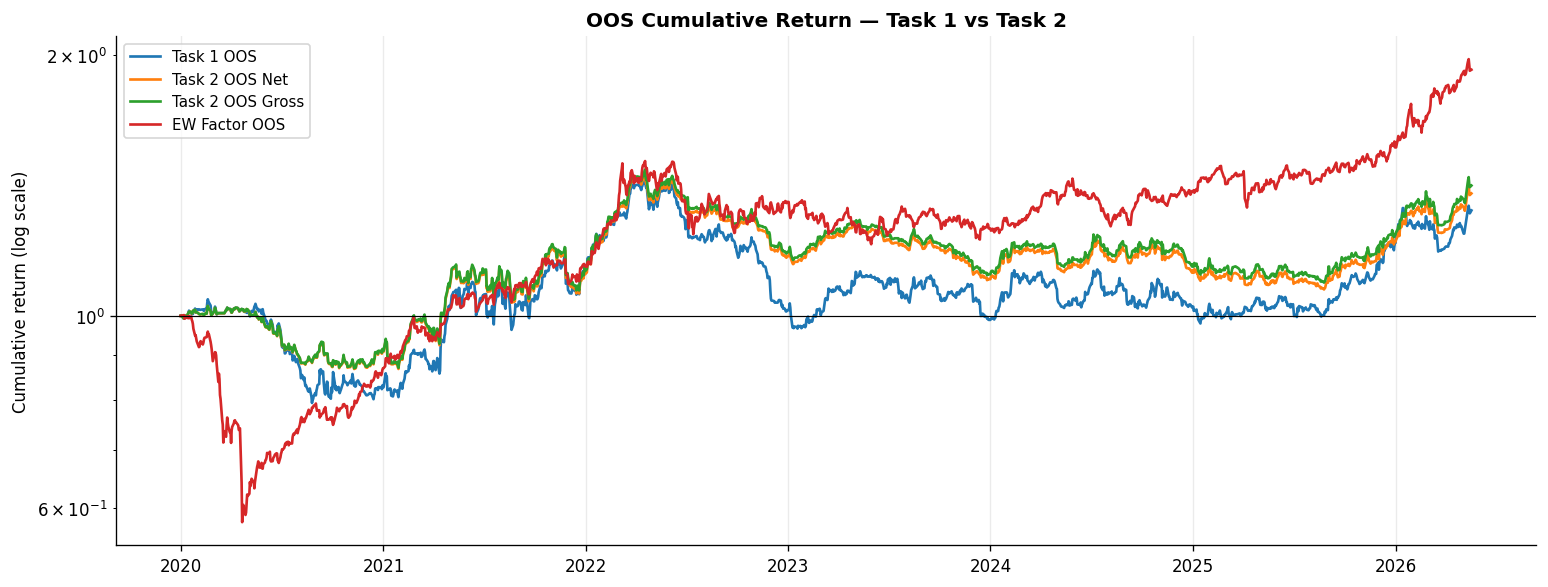

In [9]:
return_panel = pd.concat({
    'Task 1 OOS': ret_task1_oos,
    'Task 2 OOS Net': ret_task2_net_oos,
    'Task 2 OOS Gross': ret_task2_gross_oos,
    'EW Factor OOS': factor_oos,
}, axis=1).fillna(0.0)

cum = (1.0 + return_panel).cumprod()
fig, ax = plt.subplots(figsize=(13, 5))
for col in cum.columns:
    ax.plot(cum.index, cum[col], lw=1.6, label=col)
ax.axhline(1.0, color='black', lw=0.7)
ax.set_yscale('log')
ax.set_title('OOS Cumulative Return — Task 1 vs Task 2', fontweight='bold')
ax.set_ylabel('Cumulative return (log scale)')
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
plt.show()


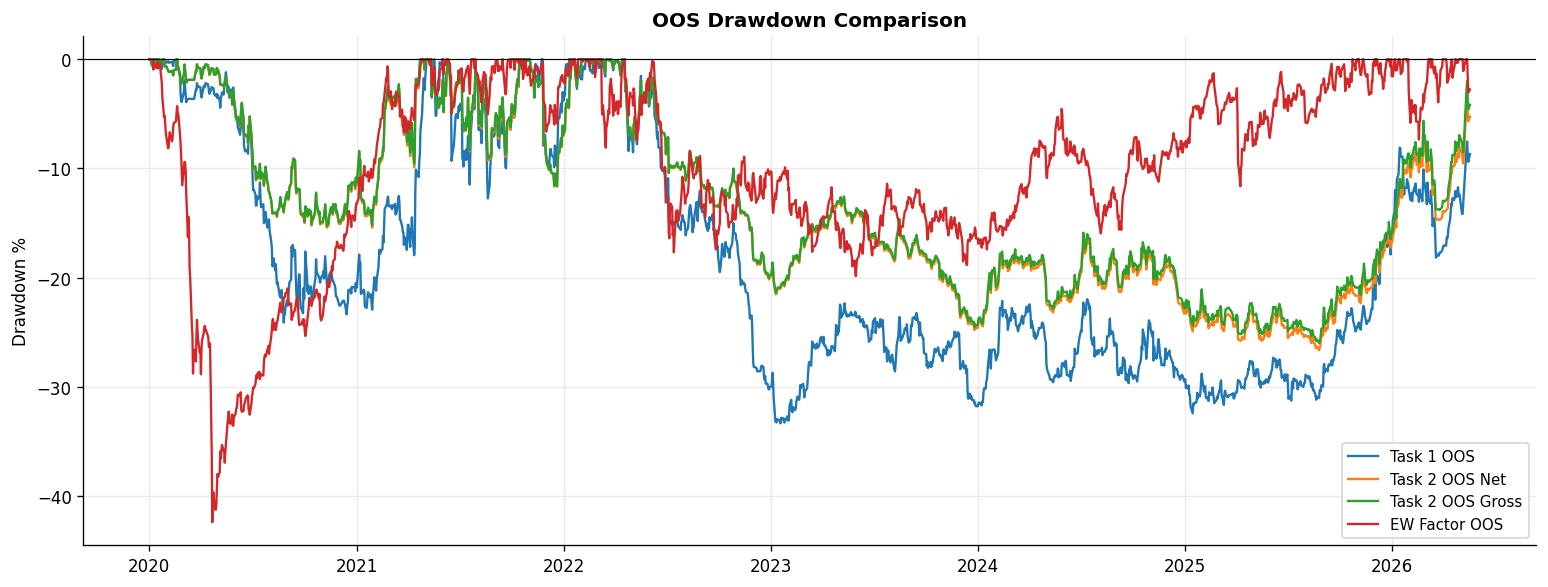

In [10]:
drawdowns = cum / cum.cummax() - 1.0
fig, ax = plt.subplots(figsize=(13, 5))
for col in drawdowns.columns:
    ax.plot(drawdowns.index, drawdowns[col] * 100, lw=1.4, label=col)
ax.axhline(0.0, color='black', lw=0.7)
ax.set_title('OOS Drawdown Comparison', fontweight='bold')
ax.set_ylabel('Drawdown %')
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
plt.show()


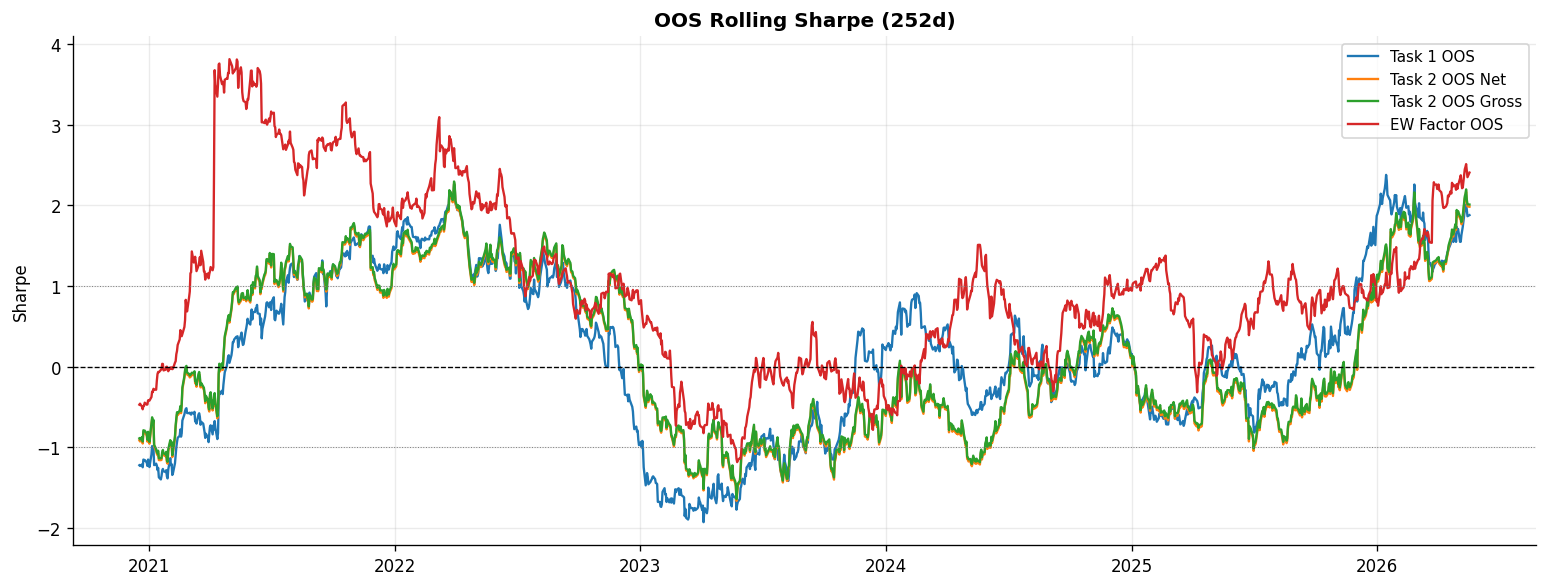

In [11]:
rolling = pd.DataFrame({col: rolling_sharpe(return_panel[col], window=252) for col in return_panel.columns}).dropna(how='all')

fig, ax = plt.subplots(figsize=(13, 5))
for col in rolling.columns:
    ax.plot(rolling.index, rolling[col], lw=1.4, label=col)
ax.axhline(0.0, color='black', lw=0.8, ls='--')
ax.axhline(1.0, color='grey', lw=0.6, ls=':')
ax.axhline(-1.0, color='grey', lw=0.6, ls=':')
ax.set_title('OOS Rolling Sharpe (252d)', fontweight='bold')
ax.set_ylabel('Sharpe')
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
plt.show()


,Entries,Short Entries,Avg Open Positions,Avg Gross Exposure
Task 1,554.0,201.0,5.942,1.069
Task 2,596.0,138.0,3.962,0.691


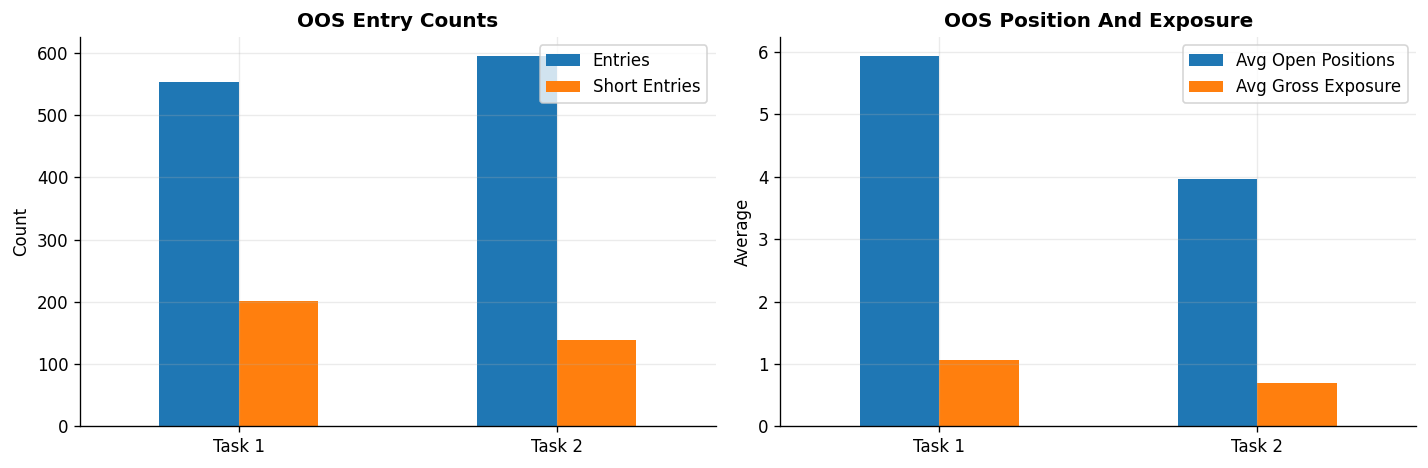

In [12]:
position_diag = pd.DataFrame({
    'Task 1': {
        'Entries': _entry_count(pos_task1_oos),
        'Short Entries': _short_entry_count(pos_task1_oos),
        'Avg Open Positions': (pos_task1_oos != 0).sum(axis=1).mean(),
        'Avg Gross Exposure': wgt_task1_oos.abs().sum(axis=1).mean(),
    },
    'Task 2': {
        'Entries': _entry_count(pos_task2_oos),
        'Short Entries': _short_entry_count(pos_task2_oos),
        'Avg Open Positions': (pos_task2_oos != 0).sum(axis=1).mean(),
        'Avg Gross Exposure': wgt_task2_oos.abs().sum(axis=1).mean(),
    },
}).T

display(position_diag.round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
position_diag[['Entries', 'Short Entries']].plot(kind='bar', ax=axes[0], rot=0)
axes[0].set_title('OOS Entry Counts', fontweight='bold')
axes[0].set_ylabel('Count')
position_diag[['Avg Open Positions', 'Avg Gross Exposure']].plot(kind='bar', ax=axes[1], rot=0)
axes[1].set_title('OOS Position And Exposure', fontweight='bold')
axes[1].set_ylabel('Average')
for ax in axes:
    ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
plt.show()
